# Day 32 Exercises
Add dropout, batch norm, weight decay, early stopping; sweep learning rate.

### 1. Imports
First, let's import the necessary libraries. We'll use PyTorch for the model and training, TorchVision for the dataset, and Matplotlib for visualizing the results.

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt


### 2. Dataset Loading
We are going to use the **MNIST** dataset for this exercise. We define standard transformations to normalize the data, which helps neural networks learn faster and more stably.

In [2]:
transform = transforms.Compose([transforms.ToTensor(), transforms.Normalize((0.5,), (0.5,))])
train_dataset = datasets.MNIST(root='./data', train=True, download=True, transform=transform)
test_dataset = datasets.MNIST(root='./data', train=False, download=True, transform=transform)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)


### 3. Model Definition (Dropout & BatchNorm)
Here we define our multi-layer perceptron (MLP). To fight overfitting and stabilize training, we inject:
- **Batch Normalization** (`nn.BatchNorm1d`): Normalizes activations within a batch to prevent internal covariate shift.
- **Dropout** (`nn.Dropout`): Randomly zeros out some activations to prevent reliance on specific features.

In [3]:
class RobustMLP(nn.Module):
    def __init__(self):
        super(RobustMLP, self).__init__()
        self.fc1 = nn.Linear(28*28, 256)
        self.bn1 = nn.BatchNorm1d(256)
        self.dropout1 = nn.Dropout(0.3)
        
        self.fc2 = nn.Linear(256, 128)
        self.bn2 = nn.BatchNorm1d(128)
        self.dropout2 = nn.Dropout(0.3)
        
        self.fc3 = nn.Linear(128, 10)

    def forward(self, x):
        x = x.view(-1, 28*28)
        x = torch.relu(self.bn1(self.fc1(x)))
        x = self.dropout1(x)
        x = torch.relu(self.bn2(self.fc2(x)))
        x = self.dropout2(x)
        x = self.fc3(x)
        return x


### 4. Training Loop (Weight Decay & Early Stopping)
The training function orchestrates the learning process. It accepts `lr` (learning rate) and `weight_decay` (L2 regularization).
It also tracks the validation loss to implement **Early Stopping** (halts training when validation loss stops improving for a specified `patience`).

In [4]:
def train_model(lr, weight_decay, patience=2, epochs=5):
    model = RobustMLP()
    criterion = nn.CrossEntropyLoss()
    # Note the weight_decay parameter added here for L2 regularization
    optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    
    best_loss = float('inf')
    epochs_no_improve = 0
    train_losses, val_losses = [], []
    
    for epoch in range(epochs):
        # --- Training Phase ---
        model.train()
        running_loss = 0.0
        for inputs, labels in train_loader:
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            running_loss += loss.item()
            
        avg_train_loss = running_loss / len(train_loader)
        train_losses.append(avg_train_loss)
        
        # --- Validation Phase ---
        model.eval()
        val_loss = 0.0
        correct = 0
        total = 0
        with torch.no_grad():
            for inputs, labels in test_loader:
                outputs = model(inputs)
                loss = criterion(outputs, labels)
                val_loss += loss.item()
                _, predicted = torch.max(outputs.data, 1)
                total += labels.size(0)
                correct += (predicted == labels).sum().item()
                
        avg_val_loss = val_loss / len(test_loader)
        val_losses.append(avg_val_loss)
        accuracy = 100 * correct / total
        print(f'Epoch {epoch+1}, Train Loss: {avg_train_loss:.4f}, Val Loss: {avg_val_loss:.4f}, Val Acc: {accuracy:.2f}%')
        
        # --- Early Stopping Check ---
        if avg_val_loss < best_loss:
            best_loss = avg_val_loss
            epochs_no_improve = 0
        else:
            epochs_no_improve += 1
            if epochs_no_improve >= patience:
                print('Early stopping triggered!')
                break
                
    return train_losses, val_losses, accuracy


### 5. Learning Rate Sweep & Plotting
Now we run our training loop over different learning rate values (`0.01`, `0.001`, `0.0001`) while keeping other hyperparameters constant.
Afterwards, we visualize the validation losses to identify which learning rate converged fastest or produced the most stable performance.


--- Training with learning rate: 0.01 ---
Epoch 1, Train Loss: 0.2913, Val Loss: 0.1330, Val Acc: 95.89%
Epoch 2, Train Loss: 0.2149, Val Loss: 0.1151, Val Acc: 96.31%
Epoch 3, Train Loss: 0.2124, Val Loss: 0.1239, Val Acc: 95.96%
Epoch 4, Train Loss: 0.2073, Val Loss: 0.1434, Val Acc: 95.58%
Early stopping triggered!

--- Training with learning rate: 0.001 ---
Epoch 1, Train Loss: 0.3015, Val Loss: 0.1093, Val Acc: 96.56%
Epoch 2, Train Loss: 0.1543, Val Loss: 0.0833, Val Acc: 97.38%
Epoch 3, Train Loss: 0.1242, Val Loss: 0.0779, Val Acc: 97.51%
Epoch 4, Train Loss: 0.1065, Val Loss: 0.0698, Val Acc: 97.88%
Epoch 5, Train Loss: 0.0972, Val Loss: 0.0671, Val Acc: 97.77%

--- Training with learning rate: 0.0001 ---
Epoch 1, Train Loss: 0.7262, Val Loss: 0.2788, Val Acc: 93.32%
Epoch 2, Train Loss: 0.3012, Val Loss: 0.1667, Val Acc: 95.52%
Epoch 3, Train Loss: 0.2170, Val Loss: 0.1253, Val Acc: 96.34%
Epoch 4, Train Loss: 0.1775, Val Loss: 0.1056, Val Acc: 96.86%
Epoch 5, Train Loss: 0.

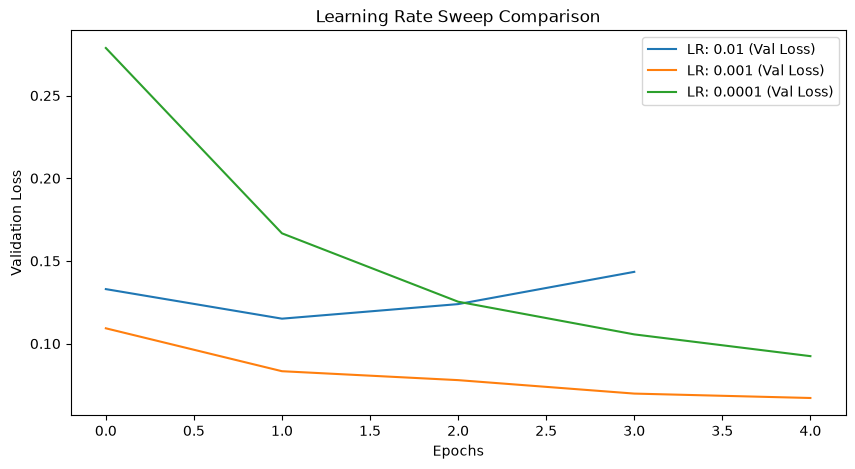

In [5]:
lrs = [0.01, 0.001, 0.0001]
results = {}

for lr in lrs:
    print(f'\n--- Training with learning rate: {lr} ---')
    # we use weight_decay=1e-4 and a patience of 2 for early stopping
    t_loss, v_loss, acc = train_model(lr=lr, weight_decay=1e-4, patience=2, epochs=5)
    results[lr] = {'train': t_loss, 'val': v_loss, 'accuracy': acc}

# Plotting sweep results
plt.figure(figsize=(10, 5))
for lr, res in results.items():
    plt.plot(res['val'], label=f'LR: {lr} (Val Loss)')

plt.xlabel('Epochs')
plt.ylabel('Validation Loss')
plt.title('Learning Rate Sweep Comparison')
plt.legend()
plt.show()
